In [1]:
import pandas as pd
import numpy as np
import torch
import torch_geometric

/Users/tolgakuntman/miniconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
commit_info = pd.read_csv("../data/processed/commit_info.csv")
file_info = pd.read_csv("../data_new/processed/file_info_new.csv")
function_info = pd.read_csv("../data_new/processed/function_info_new.csv")
file_info.head()

,hash,commit_label,filename,old_path,new_path,change_type,diff,diff_parsed,num_lines_added,num_lines_deleted,code_after,code_before,num_method_changed,num_lines_of_code,complexity,token_count
0,462f35ad5de538cf5961806918a18c22add92c00,VCC,tpm_kdfa.c,src/tpm_kdfa.c,src/tpm_kdfa.c,MODIFY,NaN,NaN,0,0,NaN,//********************************************...,1,94,5,392
1,c5d72beaab1cbbbe68271f4bc4b6670d69985157,FC,tpm_kdfa.c,src/tpm_kdfa.c,lib/tpm_kdfa.c,MODIFY,NaN,NaN,0,0,//********************************************...,NaN,2,153,15,642
2,462f35ad5de538cf5961806918a18c22add92c00,VCC,tpm_kdfa.h,src/tpm_kdfa.h,src/tpm_kdfa.h,MODIFY,NaN,NaN,0,0,NaN,//********************************************...,0,49,0,0
3,c5d72beaab1cbbbe68271f4bc4b6670d69985157,FC,tpm_kdfa.h,src/tpm_kdfa.h,lib/tpm_kdfa.h,MODIFY,NaN,NaN,0,0,//********************************************...,NaN,0,49,0,0
4,462f35ad5de538cf5961806918a18c22add92c00,VCC,tpm_session.c,src/tpm_session.c,src/tpm_session.c,MODIFY,NaN,NaN,0,0,NaN,//********************************************...,5,267,26,1017


In [4]:
tensorflow_commits = commit_info[commit_info["repo_url"].str.contains("tensorflow", case=False, na=False)]
print(f"Total commits: {len(commit_info)}")
print(f"TensorFlow commits: {len(tensorflow_commits)}")
tensorflow_commits.head()

Total commits: 8796
TensorFlow commits: 835


,hash,msg,author,author_date,author_timezone,committer,committer_date,committer_timezone,in_main_branch,merge,...,num_lines_deleted,num_lines_added,num_lines_changed,num_files_changed,dmm_unit_size,dmm_unit_complexity,dmm_unit_interfacing,commit_type,cwe_id,repo_url
5935,15c609314179015e7c1bc1add9ccd141908dcdbc,Automated sync from github.com/tensorflow/tens...,41898282+github-actions[bot]@users.noreply.git...,2021-05-03 20:02:56+00:00,0,noreply@github.com,2021-05-03 20:02:56+00:00,0,True,False,...,0,526,526,6,0.508108,0.732432,0.772973,VCC,CWE-125,https://github.com/tensorflow/tflite-micro
5936,4142e47e9e31db481781b955ed3ff807a781b494,GatherNd verifies that an index is valid befor...,alankelly@google.com,2022-07-26 21:54:47+02:00,-7200,noreply@github.com,2022-07-26 19:54:47+00:00,0,True,False,...,12,51,63,2,0.666667,0.878788,0.666667,FC,CWE-125,https://github.com/tensorflow/tflite-micro
7814,2e465ed0d39c429c4fb292184d86a70432bf56ac,Merged commit includes the following changes:\...,gardener@tensorflow.org,2018-05-28 23:48:17-04:00,14400,gardener@tensorflow.org,2018-05-30 12:52:37-04:00,14400,True,False,...,0,6551,6551,38,0.169869,0.736810,0.852699,VCC,CWE-121,https://github.com/tensorflow/serving
7815,d6914ba17ff2557ad91809807d61699db18255cd,Accept integers in input requests where float/...,awk@google.com,2018-10-02 22:45:24-07:00,25200,gardener@tensorflow.org,2018-10-02 22:45:54-07:00,25200,True,False,...,71,174,245,3,0.088889,0.944444,0.944444,VCC,CWE-121,https://github.com/tensorflow/serving
7816,a17c89202e68bf19f369b9cbc97db7ced283b874,Add error messages for specific cases when jso...,charles.v@nssearch.com,2018-10-12 22:29:29-03:00,10800,charles.v@nssearch.com,2018-10-22 10:51:15-03:00,10800,True,False,...,14,40,54,2,0.000000,0.000000,0.440000,VCC,CWE-121,https://github.com/tensorflow/serving


In [10]:
# Commits with more than one file changed, filtered to tensorflow
tf_hashes = set(tensorflow_commits["hash"])
tf_file_info = file_info[file_info["hash"].isin(tf_hashes)]

files_per_commit = tf_file_info.groupby("hash")["filename"].count().reset_index()
files_per_commit.columns = ["hash", "num_files"]

multi_file_hashes = files_per_commit[files_per_commit["num_files"] > 1]["hash"]

# Join with commit_info to get temporal info and sort
multi_file_commits = tensorflow_commits[tensorflow_commits["hash"].isin(multi_file_hashes)].copy()
multi_file_commits = multi_file_commits.merge(files_per_commit, on="hash", how="left")
multi_file_commits["author_date"] = pd.to_datetime(multi_file_commits["author_date"], utc=True)
multi_file_commits = multi_file_commits.sort_values("author_date").reset_index(drop=True)

print(f"TensorFlow commits with > 1 file changed: {len(multi_file_commits)}")
multi_file_commits[["hash", "author_date", "num_files", "commit_type"]].head(20)


TensorFlow commits with > 1 file changed: 100


,hash,author_date,num_files,commit_type
0,4213ac97be449d0e40631a314d2b7bd3901d4967,2015-11-17 07:42:32+00:00,2,VCC
1,d552be23658b3bdd1b7dedd34f25631773e81dff,2016-01-22 17:55:02+00:00,2,VCC
2,8509f88ade3fc65f4cc530780d06100f0b1ea108,2016-02-26 18:22:06+00:00,2,VCC
3,6a187ccddaebb741ea77fc3201c6e36625f0aadb,2016-05-04 15:46:46+00:00,2,VCC
4,cc40cd3b0a8b83f5ee071b7ee32c17b56815a89c,2016-06-15 06:47:37+00:00,3,VCC
5,88686b308146887a88903c883bed7affc650e076,2016-08-08 20:27:33+00:00,2,VCC
6,0822c9393ab0610311c954ec370b5a8fe2397af7,2016-09-09 01:40:18+00:00,2,VCC
7,f803bd7c5338d522d262314bd1e0eb4021367c3d,2016-11-11 00:47:07+00:00,2,VCC
8,7abbdf2699d0c84e9c9fa2ffe9eb76d848d7be9f,2016-11-22 01:41:06+00:00,2,VCC
9,1e67c90e2caceeff82d09793d1ef5fa0300d219b,2017-01-09 20:04:37+00:00,2,VCC


In [15]:
target_hash = "a5a51ad3a1200e2e5ef46c140bab717422e41ca2"

commit = commit_info[commit_info["hash"] == target_hash]
files = file_info[file_info["hash"] == target_hash]
functions = function_info[function_info["hash"] == target_hash]

print(f"Commit:\n"); display(commit)
print(f"\nFiles ({len(files)}):\n"); display(files)
print(f"\nFunctions ({len(functions)}):\n"); display(functions)


Commit:



,hash,msg,author,author_date,author_timezone,committer,committer_date,committer_timezone,in_main_branch,merge,...,num_lines_deleted,num_lines_added,num_lines_changed,num_files_changed,dmm_unit_size,dmm_unit_complexity,dmm_unit_interfacing,commit_type,cwe_id,repo_url
8104,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,Adding a depthwise convolution kernel op (with...,gardener@tensorflow.org,2018-04-30 06:59:23-07:00,25200,gardener@tensorflow.org,2018-04-30 07:01:55-07:00,25200,True,False,...,238,637,875,11,0.0,0.0,0.6875,VCC,CWE-369,https://github.com/tensorflow/tensorflow



Files (2):



,hash,commit_label,filename,old_path,new_path,change_type,diff,diff_parsed,num_lines_added,num_lines_deleted,code_after,code_before,num_method_changed,num_lines_of_code,complexity,token_count
2609,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,VCC,conv_ops.cc,tensorflow/core/kernels/conv_ops.cc,tensorflow/core/kernels/conv_ops.cc,MODIFY,NaN,NaN,0,0,NaN,/* Copyright 2015 The TensorFlow Authors. All ...,11,860,78,4699
2967,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,VCC,conv_grad_ops.cc,tensorflow/core/kernels/conv_grad_ops.cc,tensorflow/core/kernels/conv_grad_ops.cc,MODIFY,NaN,NaN,0,0,NaN,/* Copyright 2015 The TensorFlow Authors. All ...,4,164,12,931



Functions (2):



,hash,commit_label,name,filename,num_lines_of_code,complexity,token_count,parameters,signature,start_line,end_line,length,top_nesting_level,code,before_change
2701,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,VCC,"tensorflow::LaunchConv2DOp<GPUDevice,T>::opera...",conv_ops.cc,264,38,2099,"['ctx', 'use_cudnn', 'cudnn_use_autotune', 'in...","tensorflow::LaunchConv2DOp<GPUDevice,T>::opera...",497,803,307,1,"void LaunchConv2DOp<GPUDevice, T>::operator()(...",True
3127,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,VCC,tensorflow::ConvBackpropComputeDimensionsV2,conv_grad_ops.cc,49,8,394,"['label', 'num_spatial_dims', 'input_shape', '...",tensorflow::ConvBackpropComputeDimensionsV2( S...,97,149,53,1,Status ConvBackpropComputeDimensionsV2(\n S...,True


In [16]:
from torch_geometric.data import HeteroData

# ── 1. Node feature tensors ──────────────────────────────────────────────────

commit_feat_cols = ["num_lines_deleted", "num_lines_added", "num_lines_changed",
                    "num_files_changed", "dmm_unit_size", "dmm_unit_complexity",
                    "dmm_unit_interfacing"]
file_feat_cols   = ["num_lines_added", "num_lines_deleted", "num_method_changed",
                    "num_lines_of_code", "complexity", "token_count"]
func_feat_cols   = ["num_lines_of_code", "complexity", "token_count",
                    "length", "top_nesting_level"]

commit_feats = commit[commit_feat_cols].fillna(0).values.astype("float32")
file_feats   = files[file_feat_cols].fillna(0).values.astype("float32")
func_feats   = functions[func_feat_cols].fillna(0).values.astype("float32")

# ── 2. Build local index maps ────────────────────────────────────────────────

# files: 0 … num_files-1  (reset_index already done via filtering)
files_reset = files.reset_index(drop=True)
filename_to_file_idx = {row["filename"]: i for i, row in files_reset.iterrows()}

functions_reset = functions.reset_index(drop=True)

# ── 3. Edge index: commit → file  (one commit, all files) ───────────────────
num_files = len(files_reset)
commit_to_file_src = torch.zeros(num_files, dtype=torch.long)          # always node 0
commit_to_file_dst = torch.arange(num_files, dtype=torch.long)
commit_to_file_edge = torch.stack([commit_to_file_src, commit_to_file_dst])

# ── 4. Edge index: file → function  (matched by filename) ───────────────────
file_src, func_dst = [], []
for func_idx, row in functions_reset.iterrows():
    f_idx = filename_to_file_idx.get(row["filename"])
    if f_idx is not None:
        file_src.append(f_idx)
        func_dst.append(func_idx)

file_to_func_edge = torch.tensor([file_src, func_dst], dtype=torch.long)

# ── 5. Assemble HeteroData ───────────────────────────────────────────────────
data = HeteroData()

data["commit"].x              = torch.tensor(commit_feats)
data["file"].x                = torch.tensor(file_feats)
data["function"].x            = torch.tensor(func_feats)

data["commit", "has", "file"].edge_index         = commit_to_file_edge
data["file",   "has", "function"].edge_index     = file_to_func_edge

print(data)
print(f"\nNodes  — commit: {data['commit'].x.shape}, file: {data['file'].x.shape}, function: {data['function'].x.shape}")
print(f"Edges  — commit→file: {commit_to_file_edge.shape}, file→function: {file_to_func_edge.shape}")


HeteroData(
  commit={ x=[1, 7] },
  file={ x=[2, 6] },
  function={ x=[2, 5] },
  (commit, has, file)={ edge_index=[2, 2] },
  (file, has, function)={ edge_index=[2, 2] }
)

Nodes  — commit: torch.Size([1, 7]), file: torch.Size([2, 6]), function: torch.Size([2, 5])
Edges  — commit→file: torch.Size([2, 2]), file→function: torch.Size([2, 2])


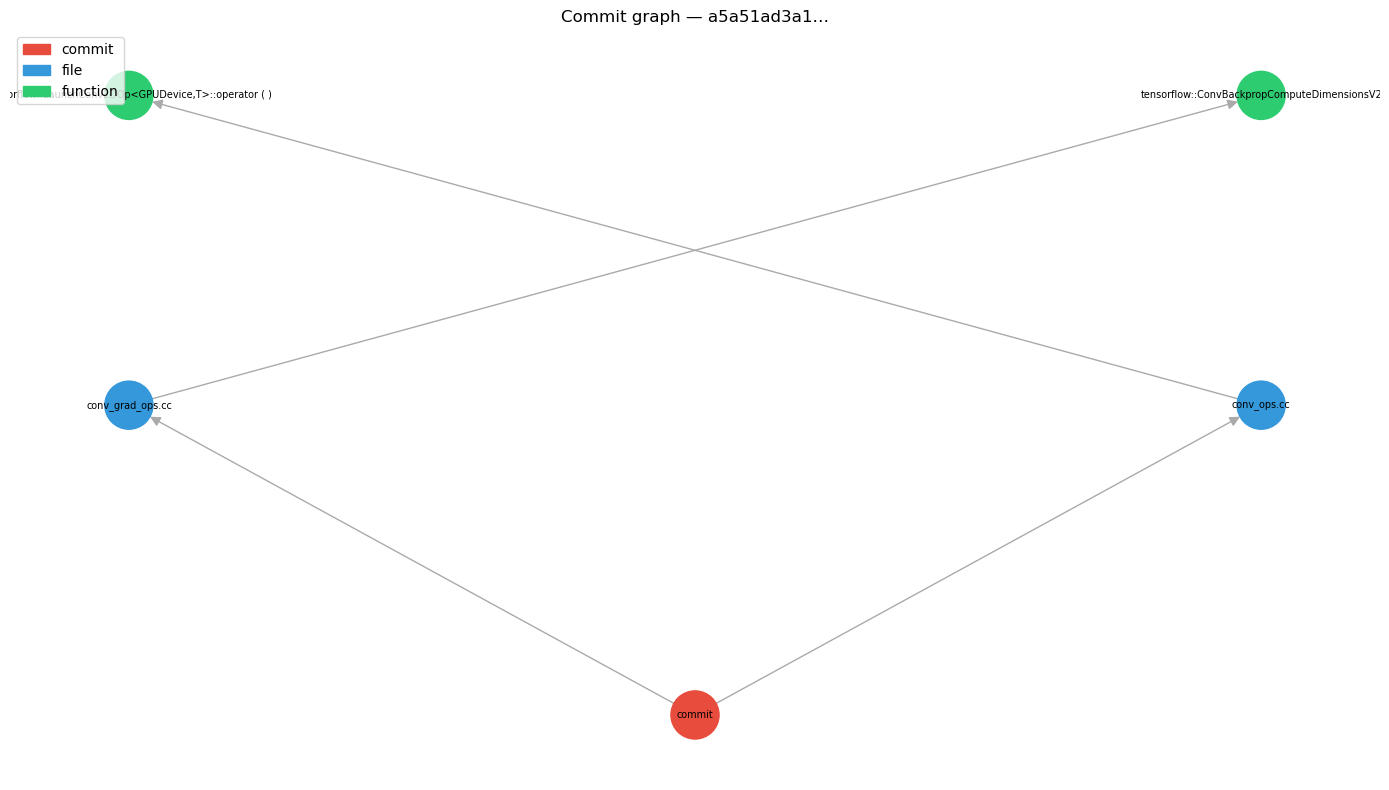

In [17]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

G = nx.DiGraph()

# ── Add nodes with type labels ───────────────────────────────────────────────
G.add_node("commit_0", node_type="commit", label="commit")

for i, row in files_reset.iterrows():
    G.add_node(f"file_{i}", node_type="file", label=row["filename"])

for i, row in functions_reset.iterrows():
    G.add_node(f"func_{i}", node_type="function", label=row["name"])

# ── Add edges ────────────────────────────────────────────────────────────────
src, dst = commit_to_file_edge
for s, d in zip(src.tolist(), dst.tolist()):
    G.add_edge(f"commit_{s}", f"file_{d}")

src, dst = file_to_func_edge
for s, d in zip(src.tolist(), dst.tolist()):
    G.add_edge(f"file_{s}", f"func_{d}")

# ── Layout & colors ──────────────────────────────────────────────────────────
color_map = {"commit": "#e74c3c", "file": "#3498db", "function": "#2ecc71"}
node_colors = [color_map[G.nodes[n]["node_type"]] for n in G.nodes]
node_labels = {n: G.nodes[n]["label"] for n in G.nodes}

pos = nx.multipartite_layout(G, subset_key="node_type",
                              scale=2, align="horizontal")

plt.figure(figsize=(14, 8))
nx.draw_networkx(G, pos=pos, labels=node_labels, node_color=node_colors,
                 node_size=1200, font_size=7, arrows=True,
                 arrowsize=15, edge_color="#aaaaaa")

legend = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
plt.legend(handles=legend, loc="upper left")
plt.title(f"Commit graph — {target_hash[:10]}…")
plt.axis("off")
plt.tight_layout()
plt.show()
